<a href="https://colab.research.google.com/github/Nithyaag73/AI-Engineering-Journey/blob/main/Email_spam_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
data = pd.read_csv('Emails.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


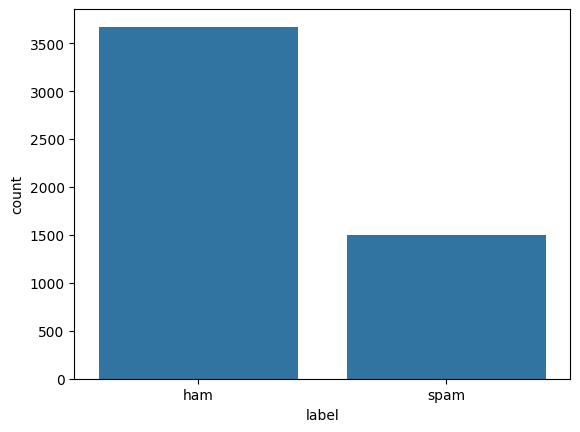

In [7]:
sns.countplot(x='label', data=data)
plt.show()

In [26]:
def clean_text(text):
    text = str(text).lower()
    text = text.replace('subject', '')

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove stopwords
    stop_words = stopwords.words('english')
    text = " ".join([word for word in text.split() if word not in stop_words])

    return text

data['text'] = data['text'].apply(clean_text)

print(data['text'].head())

0    enron methanol meter 988291 follow note gave m...
1    hpl nom january 9 2001 see attached file hplno...
2    neon retreat ho ho ho around wonderful time ye...
3    photoshop windows office cheap main trending a...
4    indian springs deal book teco pvr revenue unde...
Name: text, dtype: object


In [27]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['text']).toarray()
y = data['label'].map({'ham': 0, 'spam': 1})

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9516908212560387


In [30]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9855072463768116


In [31]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9874396135265701


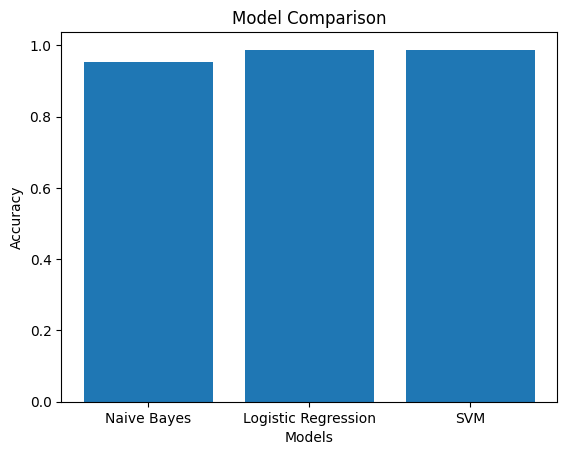

In [32]:
models = ["Naive Bayes", "Logistic Regression", "SVM"]
scores = [nb_acc, lr_acc, svm_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

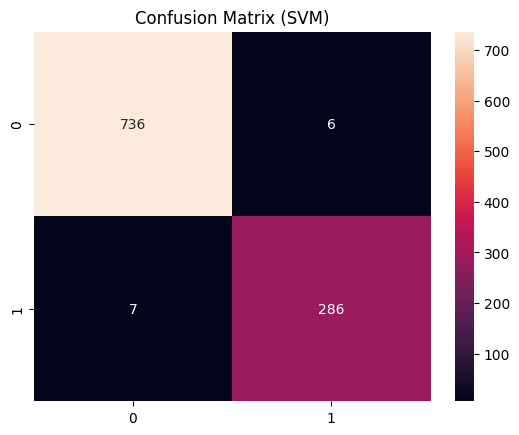

In [33]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (SVM)")
plt.show()

In [34]:
def predict_email(text, model):
    text = clean_text(text)
    vector = vectorizer.transform([text]).toarray()

    result = model.predict(vector)[0]

    return "Spam 🚨" if result == 1 else "Not Spam ✅"

In [35]:
predict_email("Congratulations! You won a free iPhone", svm_model)

'Spam 🚨'